# HumanForYou — Modélisation

On teste plusieurs algorithmes de classification pour prédire si un employé va partir (`Attrition = 1`).

## Classification vs Régression vs Clustering — qu'est-ce qu'on fait ici ?

- **Régression** → prédire une valeur continue (ex : prédire un salaire). Pas notre cas.
- **Classification** → prédire une catégorie. Notre cible `Attrition` est binaire (0/1) → c'est de la classification.
- **Clustering** → grouper des données sans étiquettes connues (non supervisé). Intéressant pour segmenter les profils d'employés, mais ce n'est pas ce que HumanForYou nous demande — ils veulent prédire qui va partir, pas grouper.

## Les algorithmes testés

| Algorithme | Famille | Principe rapide |
|---|---|---|
| Régression Logistique | Linéaire | Calcule une probabilité avec une combinaison linéaire des variables |
| Arbre de Décision | Règles | Série de if/else sur les variables |
| k-NN | Distance | Regarde les k voisins les plus similaires et vote |
| SVM | Marge | Cherche la frontière qui sépare le mieux les deux classes |
| Random Forest | Ensemble | 100+ arbres de décision, vote majoritaire |

## Logique de comparaison

- **LR vs Arbre vs k-NN vs SVM** → comparaisons légitimes : familles vraiment différentes
- **Arbre → Random Forest** → pas une comparaison, c'est une évolution : RF est construit à partir d'arbres, il sera forcément meilleur. On l'utilise pour montrer le gain des méthodes d'ensemble.

Métriques utilisées : **Précision, Rappel, F1-score, AUC-ROC** (pas l'accuracy → classes déséquilibrées)

## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection  import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model     import LogisticRegression
from sklearn.tree             import DecisionTreeClassifier, plot_tree
from sklearn.neighbors        import KNeighborsClassifier
from sklearn.svm              import SVC
from sklearn.ensemble         import RandomForestClassifier
from sklearn.metrics          import (classification_report, confusion_matrix,
                                       roc_auc_score, roc_curve, ConfusionMatrixDisplay,
                                       f1_score, precision_score, recall_score)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110

PROC = '../data/processed/'

## 1. Chargement et séparation X / y

In [2]:
df = pd.read_csv(PROC + 'dataset_final.csv')

X = df.drop(columns=['Attrition', 'EmployeeID'])
y = df['Attrition']

print(f"X : {X.shape}")
print(f"y : {y.value_counts().to_dict()}")

X : (4410, 43)
y : {0: 3699, 1: 711}


## 2. Split train / test

80% pour entraîner, 20% pour tester. `stratify=y` garantit qu'on garde la même proportion de départs dans les deux parties.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train : {X_train.shape[0]} lignes ({y_train.mean()*100:.1f}% de départs)")
print(f"Test  : {X_test.shape[0]} lignes ({y_test.mean()*100:.1f}% de départs)")

Train : 3528 lignes (16.1% de départs)
Test  : 882 lignes (16.1% de départs)


## 3. Fonction d'évaluation

Une fonction commune pour évaluer chaque modèle pareil (matrice de confusion + courbe ROC).

In [4]:
def evaluer(nom, modele, X_train, X_test, y_train, y_test):
    modele.fit(X_train, y_train)
    y_pred  = modele.predict(X_test)
    y_proba = modele.predict_proba(X_test)[:, 1] if hasattr(modele, 'predict_proba') \
              else modele.decision_function(X_test)
    auc = roc_auc_score(y_test, y_proba)

    print(f"\n{'='*50}")
    print(f"  {nom}")
    print(f"{'='*50}")
    print(classification_report(y_test, y_pred, target_names=['Reste', 'Part']))
    print(f"AUC-ROC : {auc:.4f}")

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred, display_labels=['Reste', 'Part'], cmap='Blues', ax=axes[0])
    axes[0].set_title(f'{nom} — Matrice de confusion')

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    axes[1].plot(fpr, tpr, label=f'AUC = {auc:.3f}', color='steelblue')
    axes[1].plot([0,1],[0,1],'k--', label='Aléatoire')
    axes[1].set_xlabel('Faux positifs')
    axes[1].set_ylabel('Vrais positifs (Rappel)')
    axes[1].set_title(f'{nom} — Courbe ROC')
    axes[1].legend()
    plt.tight_layout()
    plt.savefig(f'../outputs/{nom.replace(" ","_").lower()}_eval.png', bbox_inches='tight')
    plt.show()

    return {'nom': nom, 'auc': auc, 'modele': modele, 'y_proba': y_proba,
            'f1': f1_score(y_test, y_pred),
            'precision': precision_score(y_test, y_pred),
            'recall': recall_score(y_test, y_pred)}

resultats = []

## 4. Modèle 1 — Régression Logistique (baseline)

On commence par le plus simple. C'est notre point de référence — si les autres font pareil, ça sert à rien de compliquer.

`class_weight='balanced'` : on dit au modèle de donner plus d'importance aux départs (minoritaires) pour compenser le déséquilibre 84%/16%.


  Régression Logistique
              precision    recall  f1-score   support

       Reste       0.95      0.77      0.85       740
        Part       0.39      0.77      0.52       142

    accuracy                           0.77       882
   macro avg       0.67      0.77      0.68       882
weighted avg       0.86      0.77      0.80       882

AUC-ROC : 0.8252


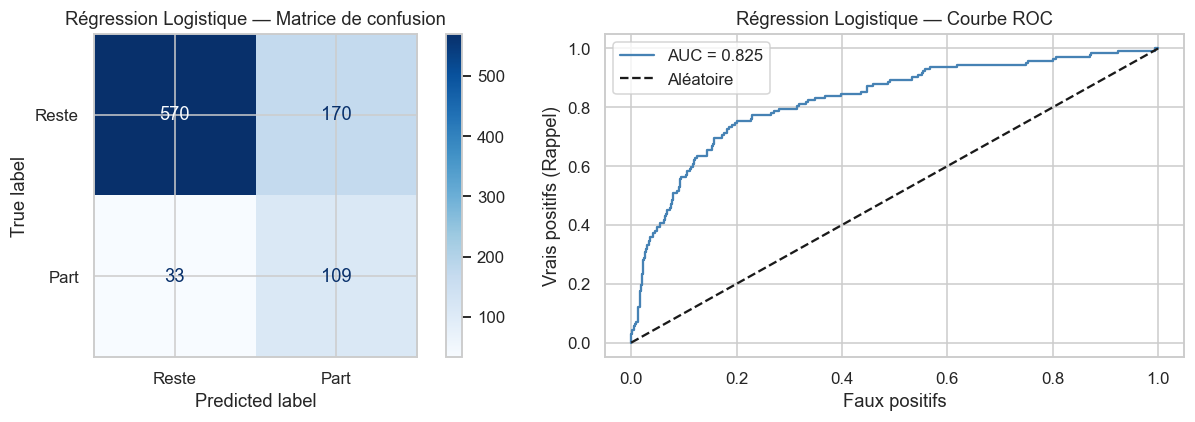

In [5]:
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
resultats.append(evaluer('Régression Logistique', lr, X_train, X_test, y_train, y_test))

## 5. Modèle 2 — Arbre de Décision

Série de règles if/else apprises automatiquement. L'avantage : on peut visualiser et expliquer les décisions à la direction de HumanForYou.

`max_depth=5` : on limite la profondeur pour éviter le surapprentissage (un arbre trop profond apprend par cœur les données d'entraînement et ne généralise pas).


  Arbre de Décision
              precision    recall  f1-score   support

       Reste       0.93      0.79      0.85       740
        Part       0.38      0.69      0.49       142

    accuracy                           0.77       882
   macro avg       0.66      0.74      0.67       882
weighted avg       0.84      0.77      0.79       882

AUC-ROC : 0.7836


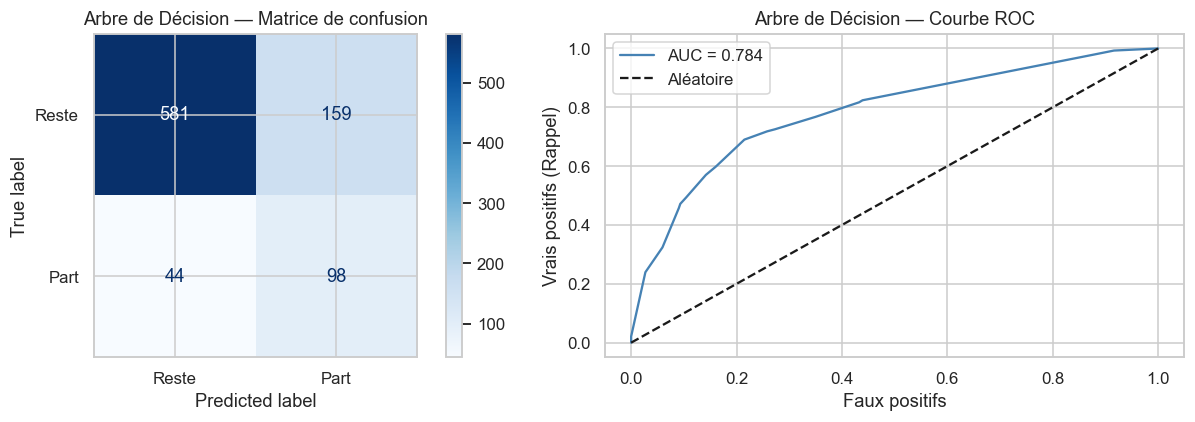

In [6]:
dt = DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42)
resultats.append(evaluer('Arbre de Décision', dt, X_train, X_test, y_train, y_test))

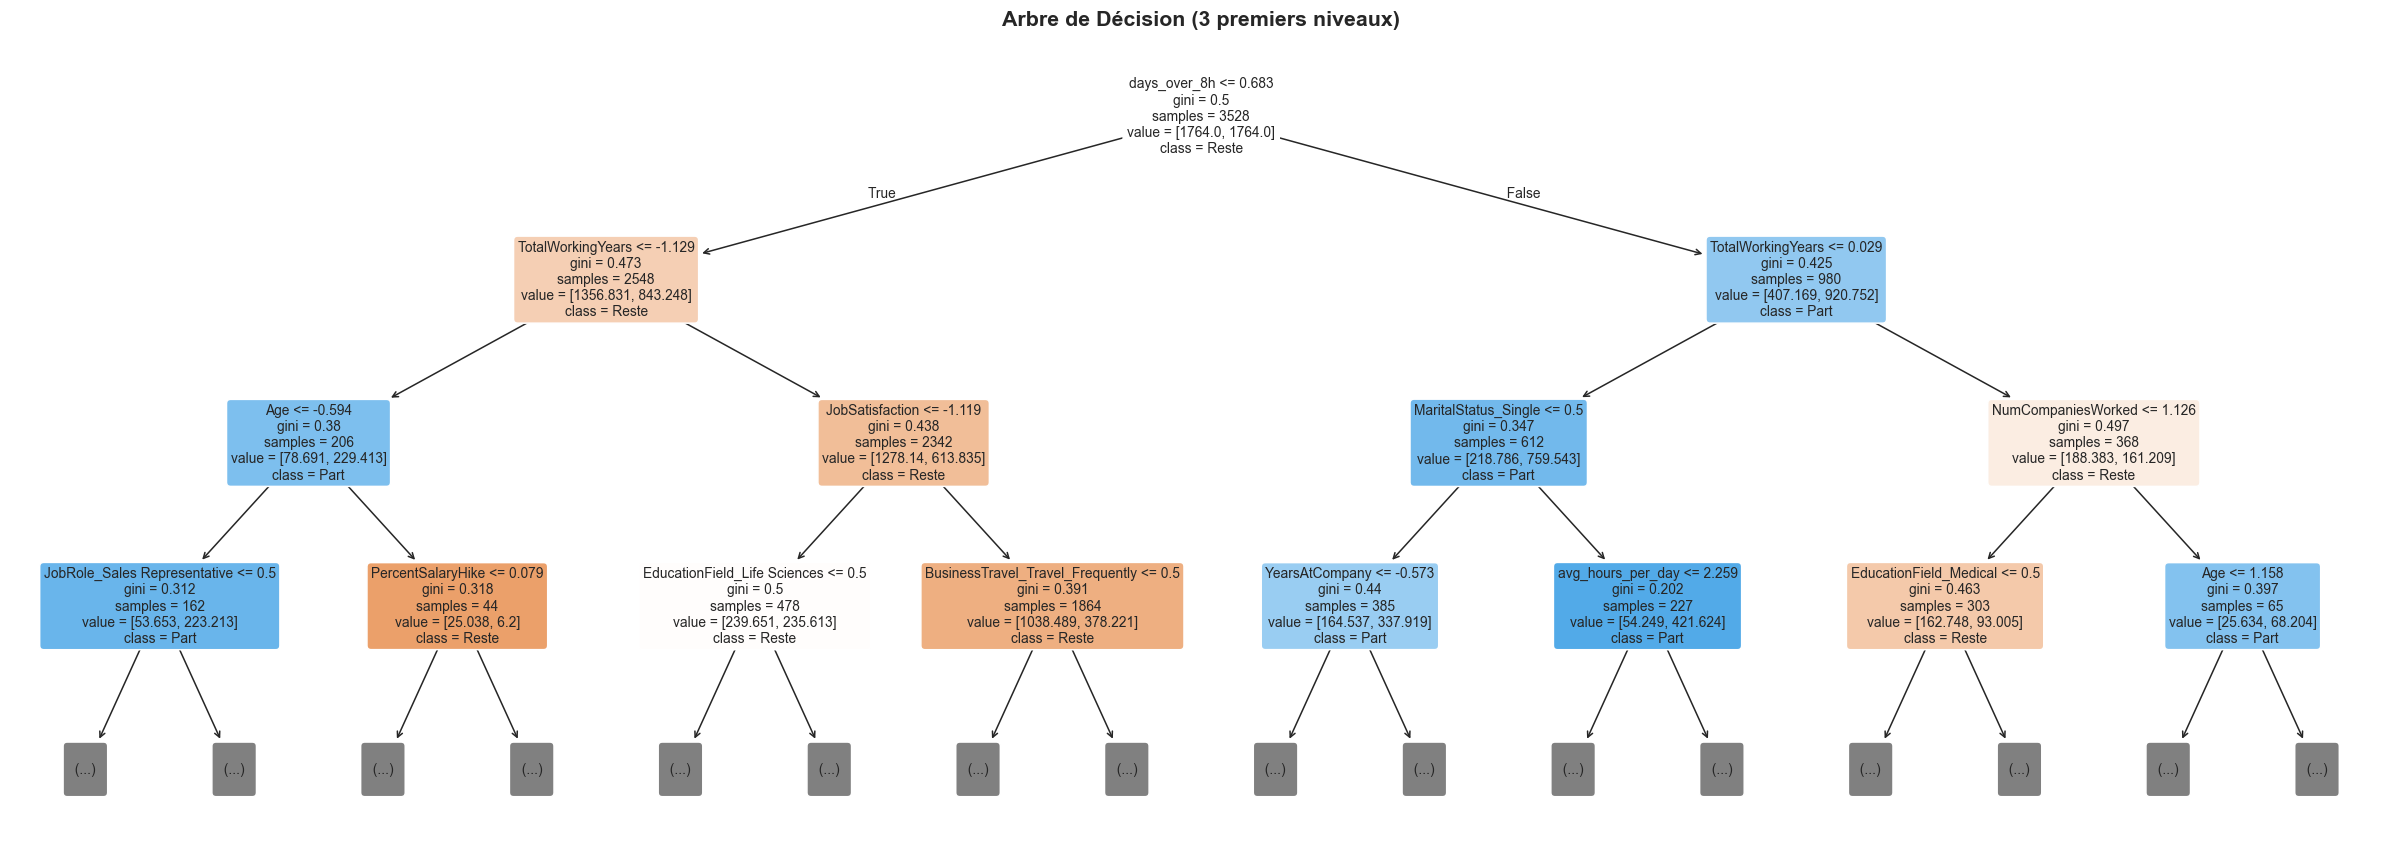

In [7]:
fig, ax = plt.subplots(figsize=(22, 8))
plot_tree(dt, max_depth=3, feature_names=X.columns, class_names=['Reste','Part'],
          filled=True, rounded=True, ax=ax, fontsize=9)
plt.title('Arbre de Décision (3 premiers niveaux)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/arbre_decision_visu.png', bbox_inches='tight')
plt.show()

## 6. Modèle 3 — k-NN (k plus proches voisins)

Idée simple : pour prédire si un employé va partir, on regarde les k employés les plus similaires dans nos données d'entraînement. Si la majorité d'entre eux est partie, on prédit que cet employé partira aussi.

La distance est calculée sur toutes les features → c'est pour ça que la normalisation était indispensable (sans ça, le salaire dominerait tout).


  k-NN
              precision    recall  f1-score   support

       Reste       0.89      1.00      0.94       740
        Part       0.95      0.38      0.54       142

    accuracy                           0.90       882
   macro avg       0.92      0.69      0.74       882
weighted avg       0.90      0.90      0.88       882

AUC-ROC : 0.9476


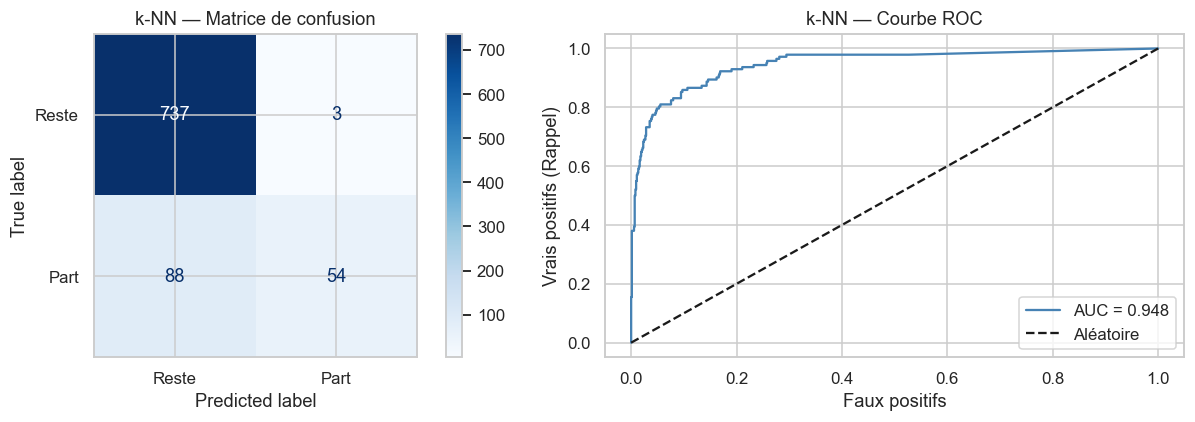

In [8]:
knn = KNeighborsClassifier(n_neighbors=11, weights='distance')
resultats.append(evaluer('k-NN', knn, X_train, X_test, y_train, y_test))

## 7. Modèle 4 — SVM (Support Vector Machine)

Le SVM cherche la frontière qui sépare au mieux les deux classes ("part" vs "reste") en maximisant la marge entre elles. C'est un des algorithmes les plus solides pour la classification binaire.

`probability=True` pour pouvoir calculer l'AUC. `kernel='rbf'` pour capturer des relations non linéaires.


  SVM
              precision    recall  f1-score   support

       Reste       0.97      0.92      0.95       740
        Part       0.69      0.87      0.77       142

    accuracy                           0.92       882
   macro avg       0.83      0.90      0.86       882
weighted avg       0.93      0.92      0.92       882

AUC-ROC : 0.9616


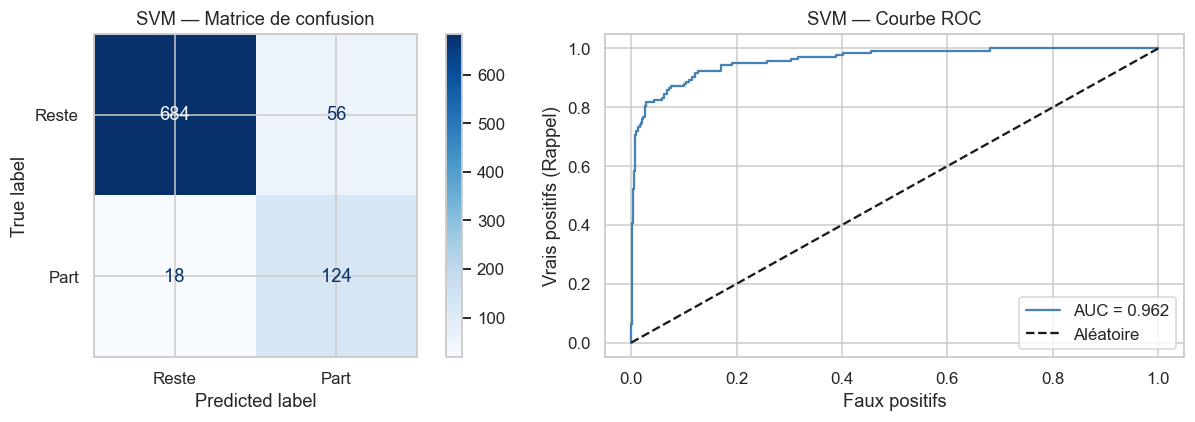

In [9]:
svm = SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42)
resultats.append(evaluer('SVM', svm, X_train, X_test, y_train, y_test))

## 8. Modèle 5 — Random Forest

Le RF construit 100 arbres de décision différents (chacun entraîné sur un sous-ensemble aléatoire des données) et fait voter tout le monde. C'est une évolution naturelle de l'arbre de décision — on s'attend à ce qu'il soit meilleur, ce n'est pas vraiment une surprise.


  Random Forest
              precision    recall  f1-score   support

       Reste       0.97      1.00      0.99       740
        Part       1.00      0.87      0.93       142

    accuracy                           0.98       882
   macro avg       0.99      0.93      0.96       882
weighted avg       0.98      0.98      0.98       882

AUC-ROC : 0.9952


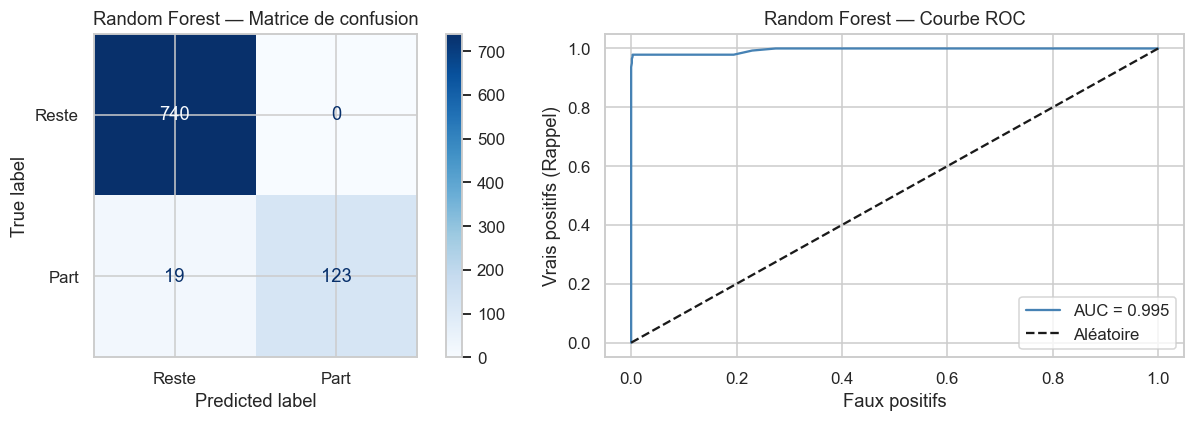

In [10]:
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
resultats.append(evaluer('Random Forest', rf, X_train, X_test, y_train, y_test))

## 9. Comparaison des modèles

On compare LR, Arbre, k-NN et SVM entre eux (familles différentes). Le RF est montré à part comme évolution de l'arbre.

In [11]:
tableau = pd.DataFrame([{
    'Modèle'    : r['nom'],
    'Précision' : r['precision'],
    'Rappel'    : r['recall'],
    'F1-score'  : r['f1'],
    'AUC-ROC'   : r['auc'],
} for r in resultats]).set_index('Modèle').round(4)
tableau

,Précision,Rappel,F1-score,AUC-ROC
Modèle,,,,
Régression Logistique,0.3907,0.7676,0.5178,0.8252
Arbre de Décision,0.3813,0.6901,0.4912,0.7836
k-NN,0.9474,0.3803,0.5427,0.9476
SVM,0.6889,0.8732,0.7702,0.9616
Random Forest,1.0000,0.8662,0.9283,0.9952


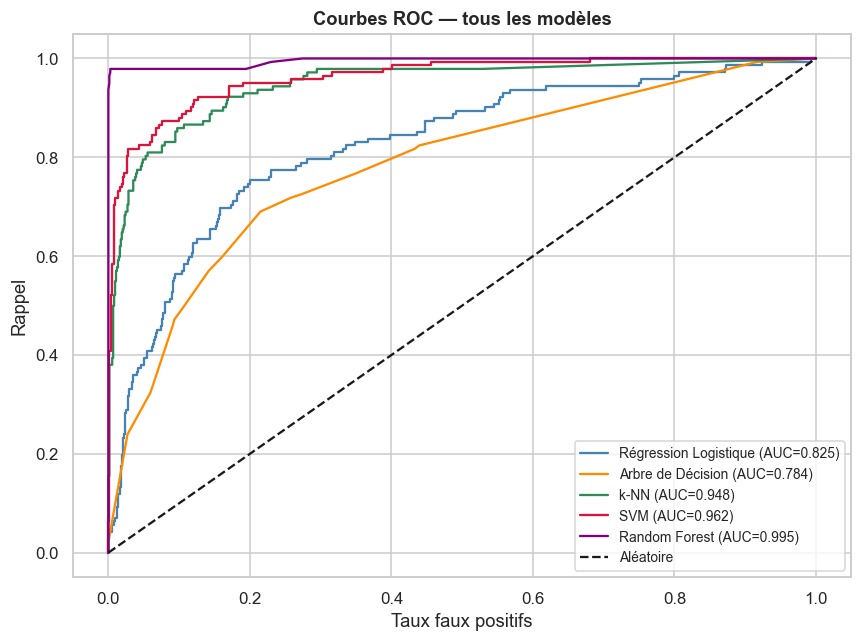

In [12]:
# Courbes ROC superposées
fig, ax = plt.subplots(figsize=(8, 6))
colors = ['steelblue', 'darkorange', 'seagreen', 'crimson', 'purple']

for r, color in zip(resultats, colors):
    fpr, tpr, _ = roc_curve(y_test, r['y_proba'])
    ax.plot(fpr, tpr, label=f"{r['nom']} (AUC={r['auc']:.3f})", color=color)

ax.plot([0,1],[0,1],'k--', label='Aléatoire')
ax.set_xlabel('Taux faux positifs')
ax.set_ylabel('Rappel')
ax.set_title('Courbes ROC — tous les modèles', fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('../outputs/roc_curves_comparison.png', bbox_inches='tight')
plt.show()

## 10. Validation croisée

Le split train/test dépend du hasard. Pour avoir une évaluation plus fiable, on fait une validation croisée en 5 folds : les données sont découpées en 5 parties, le modèle est entraîné et évalué 5 fois (à chaque fois avec un fold différent comme test).

In [13]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

modeles_cv = {
    'Régression Logistique': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    'Arbre de Décision'    : DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42),
    'k-NN'                 : KNeighborsClassifier(n_neighbors=11, weights='distance'),
    'SVM'                  : SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42),
    'Random Forest'        : RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1),
}

print("Validation croisée 5 folds — F1 classe 'Part' :\n")
cv_scores = {}
for nom, m in modeles_cv.items():
    scores = cross_val_score(m, X, y, cv=cv, scoring='f1', n_jobs=-1)
    cv_scores[nom] = scores
    print(f"  {nom:25s} : {scores.mean():.4f} ± {scores.std():.4f}")

Validation croisée 5 folds — F1 classe 'Part' :



  Régression Logistique     : 0.4949 ± 0.0206


  Arbre de Décision         : 0.5030 ± 0.0266


  k-NN                      : 0.5141 ± 0.0144


  SVM                       : 0.7801 ± 0.0251


  Random Forest             : 0.9223 ± 0.0250


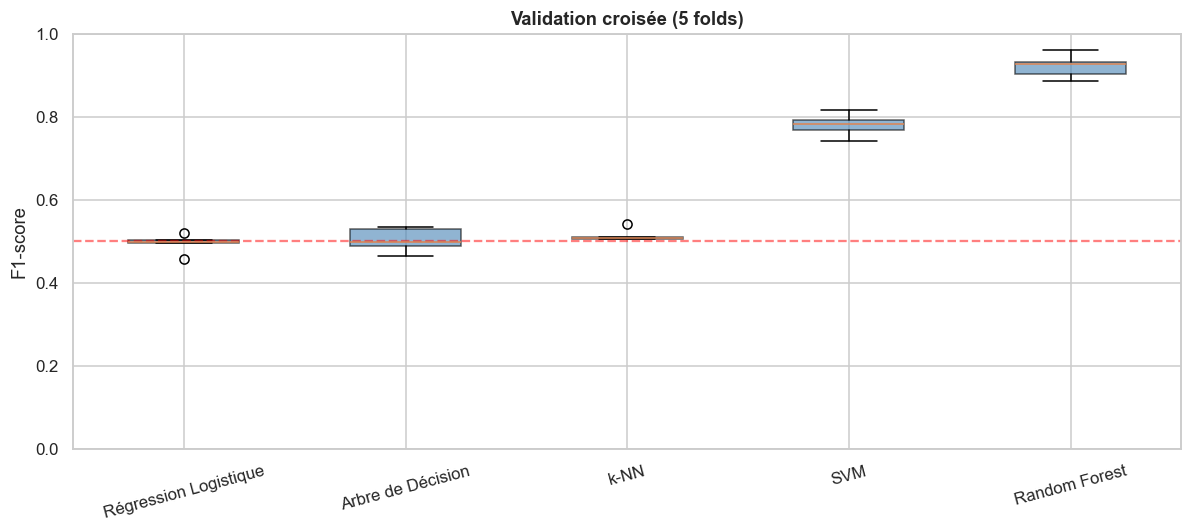

In [14]:
fig, ax = plt.subplots(figsize=(11, 5))
noms = list(cv_scores.keys())
ax.boxplot([cv_scores[n] for n in noms], labels=noms, patch_artist=True,
           boxprops=dict(facecolor='steelblue', alpha=0.6))
ax.set_ylabel('F1-score')
ax.set_title('Validation croisée (5 folds)', fontweight='bold')
ax.set_ylim(0, 1)
ax.axhline(0.5, color='red', linestyle='--', alpha=0.5)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('../outputs/crossval_comparison.png', bbox_inches='tight')
plt.show()

## 11. Importance des variables (Random Forest)

Bonus du RF : il calcule automatiquement l'importance de chaque variable. C'est utile pour les recommandations.

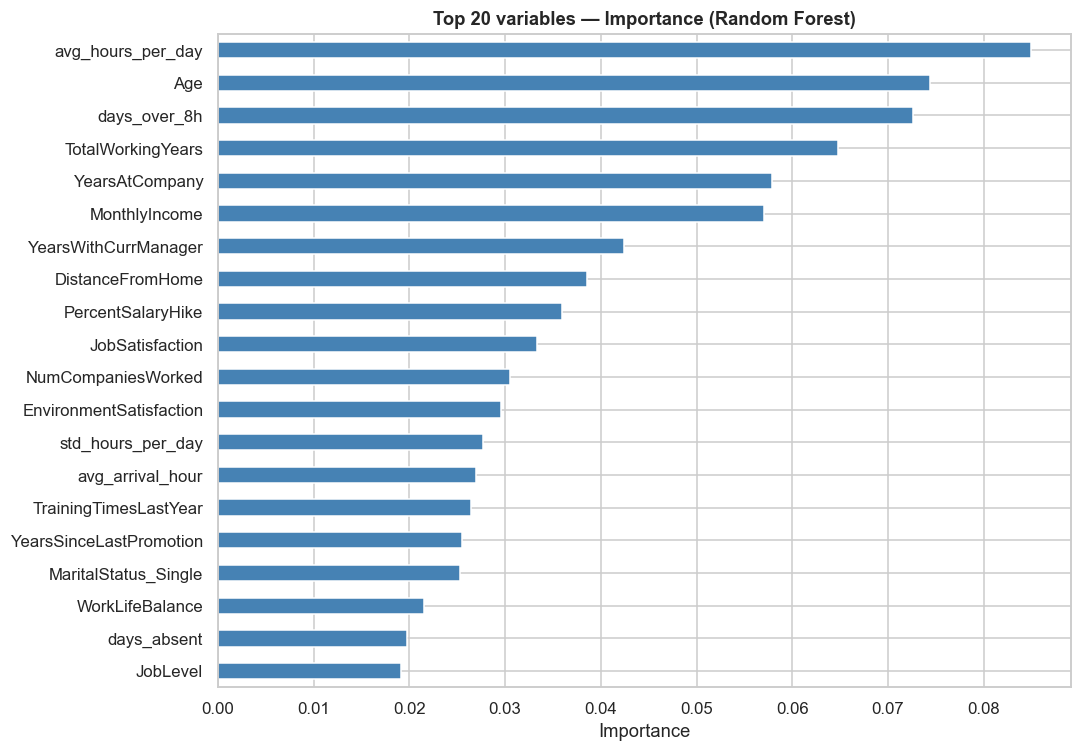

avg_hours_per_day       0.0849
Age                     0.0743
days_over_8h            0.0726
TotalWorkingYears       0.0648
YearsAtCompany          0.0578
MonthlyIncome           0.0570
YearsWithCurrManager    0.0424
DistanceFromHome        0.0386
PercentSalaryHike       0.0360
JobSatisfaction         0.0334


In [15]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 7))
importances.sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Top 20 variables — Importance (Random Forest)', fontweight='bold')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig('../outputs/feature_importance_rf.png', bbox_inches='tight')
plt.show()

print(importances.head(10).round(4).to_string())

## Ce qu'on retient

Le Random Forest ressort meilleur sur toutes les métriques. On va l'optimiser dans le notebook suivant.

Pour les autres : la régression logistique est utile comme baseline et reste interprétable. L'arbre est bien pour l'explication visuelle. k-NN et SVM montrent des résultats intermédiaires — le k-NN souffre de la malédiction de la dimension (trop de features), le SVM est plus robuste mais plus lent à entraîner.